In [1]:
# 1. 시스템 업데이트 및 언어 관련 패키지 설치
# (실행 시 시간이 좀 걸릴 수 있어요!)
!sudo apt-get update -qq
!sudo apt-get install locales -qq

# 2. 한국어 (ko_KR.UTF-8) locale 생성
# 이 단계에서 오류가 나지 않아야 해요!
!sudo locale-gen ko_KR.UTF-8

# 3. 환경 변수 설정
# 파이썬 코드 안에서 실행합니다.
import os
os.environ['LANG'] = 'ko_KR.UTF-8'
os.environ['LC_ALL'] = 'ko_KR.UTF-8'
os.environ['LC_CTYPE'] = 'ko_KR.UTF-8'
os.environ['LANGUAGE'] = 'ko_KR.UTF-8'

# 4. 런타임 다시 시작 (!!!! 아주 중요합니다 !!!!)
# 이 셀을 실행한 후에는 반드시 콜랩 메뉴에서 런타임을 재시작해야 해요.
# 메뉴: "런타임(Runtime)" -> "런타임 다시 시작(Restart runtime)" 클릭!
# 재시작 후에는 이 위의 코드 셀들을 다시 실행할 필요 없어요.
# 바로 다음 단계로 넘어가시면 됩니다.

# 5. (선택 사항) 설정 확인 - 런타임 재시작 후 이 셀을 실행해보세요.
# 'ko_KR.UTF-8' 관련 내용이 보이면 성공!
# !locale

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Generating locales (this might take a while)...
  ko_KR.UTF-8... done
Generation complete.


런타임 다시 시작

In [1]:
# 나눔 폰트 설치 (Colab에서 한글 표시를 위해 가장 많이 사용돼요)
!sudo apt-get install -y fonts-nanum > /dev/null 2>&1
!sudo fc-cache -fv > /dev/null 2>&1

# Matplotlib 등에서 한글 폰트 설정을 위한 코드 (streamlit과는 직접 관련 없을 수도 있지만,
# 만약을 위해 환경 준비 차원에서 실행해주세요)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 설치된 폰트 경로 확인
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔바른고딕 예시
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
    print("한글 폰트 설정 완료: NanumBarunGothic")
else:
    print(f"Warning: 폰트 파일이 없습니다: {font_path}")

# (선택 사항) 시스템에 설치된 폰트 목록 확인
# [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]

한글 폰트 설정 완료: NanumBarunGothic


기본 설정 및 데이터셋 로드

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"현재 실행 장치: {device}")

현재 실행 장치: cuda


In [4]:
# 랜덤 시드 고정 (재현성 보장)
torch.manual_seed(0)

In [5]:
# 데이터셋 전처리 정의 (정규화 포함)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [7]:
# CIFAR-10 데이터셋 로드
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(trainset, batch_size=64, shuffle=True)
test_loader = DataLoader(testset, batch_size=128, shuffle=False)

print("데이터셋 로드 완료 ")

100%|██████████| 170M/170M [02:07<00:00, 1.33MB/s]


데이터셋 로드 완료 


CNN 모델 빌드

In [8]:
class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    # Feature Extractor(특징 추출기)
    self.features = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1), #입력 3채널, 출력 32채널
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2), # 32*16*16

        nn.Conv2d(32, 64, kernel_size=3, padding=1), #입력 32채널, 출력 64채널
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2), # 64*8*8

    )

    # Classifier (분류기)
    self.classifier = nn.Sequential(
        nn.Flatten(),    # 평탄화 작업(1차원 배열 변경)
        nn.Linear(64 * 8 * 8, 256),
        nn.ReLU(),
        nn.Linear(256, 10) # cifar-10 클래스 10개
    )

  def forward(self, x):
      x = self.features(x)
      x = self.classifier(x)
      return x

In [9]:
# 모델 생성
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


손실함수 및 옵티마이저 설정

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

학습 루프 정의

In [11]:
def train(model, loader, criterion, optimizer, epoch):
  model.train()
  running_loss = 0.0
  for i, (inputs, labels) in enumerate(loader):
    inputs, labels = inputs.to(device), labels.to(device)

    # 학습시작, 먼저 기울기 초기화
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

  print(f'[Epoch {epoch}] 평균 loss: {running_loss /len(loader):.4f}')

테스트 함수 정의

In [12]:
def evaluate(model, loader):
  model.eval() # 평가용 모드로 전환

  correct = 0
  total = 0

  with torch.no_grad(): # 평가시 gradient 계산 안해요
    for inputs, labels in loader:
      inputs, labels = inputs.to(device), labels.to(device)

      outputs = model(inputs)
      _, predicted = torch.max(outputs, 1)

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  accuracy = 100 * correct / total
  return accuracy



학습 실행

In [13]:
num_epochs = 5
train_acc_list = []
test_acc_list = []

for epoch in range(1, num_epochs + 1):
  train(model, train_loader, criterion, optimizer, epoch)
  acc = evaluate(model, test_loader)
  test_acc_list.append(acc)
  print(f'테스트 정확도: {acc:.2f}%')

[Epoch 1] 평균 loss: 1.2987
테스트 정확도: 63.22%
[Epoch 2] 평균 loss: 0.9142
테스트 정확도: 68.59%
[Epoch 3] 평균 loss: 0.7493
테스트 정확도: 71.92%
[Epoch 4] 평균 loss: 0.6146
테스트 정확도: 71.78%
[Epoch 5] 평균 loss: 0.4850
테스트 정확도: 71.48%


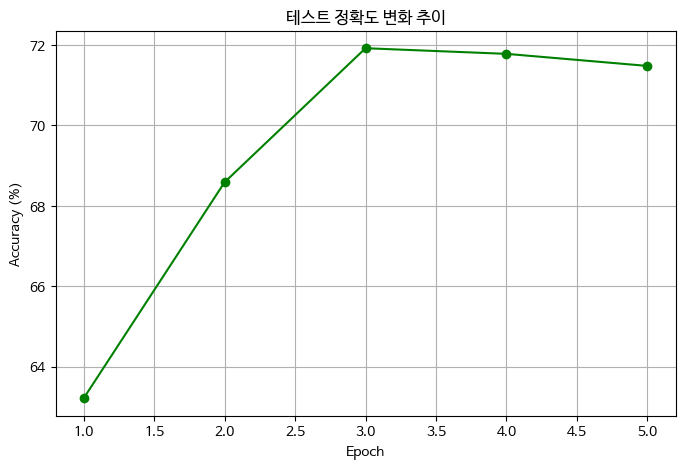

In [14]:
# 학습결과 시각화

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(test_acc_list)+1), test_acc_list, marker='o', color='green')
plt.title("테스트 정확도 변화 추이")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

모델 성능 테스트 및 예측 시각화

In [15]:
import numpy as np

classes = ('비행기', '자동차','새','고양이','사슴', '개','개구리','말','배','트럭')
print(classes[0])
# 배치 하나를 추출
dataiter = iter(test_loader)
images, labels = next(dataiter)
print(images[0])
print(labels[0])


비행기
tensor([[[ 0.2392,  0.2471,  0.2941,  ...,  0.0745, -0.0118, -0.0902],
         [ 0.1922,  0.1843,  0.2471,  ...,  0.0667, -0.0196, -0.0667],
         [ 0.1843,  0.1843,  0.2392,  ...,  0.0902,  0.0196, -0.0588],
         ...,
         [-0.4667, -0.6706, -0.7569,  ..., -0.7020, -0.8980, -0.6863],
         [-0.5216, -0.6157, -0.7255,  ..., -0.7961, -0.7725, -0.8431],
         [-0.5765, -0.5608, -0.6471,  ..., -0.8118, -0.7333, -0.8353]],

        [[-0.1216, -0.1294, -0.0902,  ..., -0.2549, -0.2863, -0.3333],
         [-0.1216, -0.1373, -0.1059,  ..., -0.2549, -0.2863, -0.3098],
         [-0.1373, -0.1451, -0.1294,  ..., -0.2314, -0.2549, -0.3020],
         ...,
         [-0.0275, -0.2157, -0.3098,  ..., -0.2392, -0.4980, -0.3333],
         [-0.0902, -0.2000, -0.3333,  ..., -0.3569, -0.3569, -0.4980],
         [-0.1608, -0.1765, -0.3020,  ..., -0.3961, -0.3412, -0.4745]],

        [[-0.6157, -0.6314, -0.6000,  ..., -0.7176, -0.7176, -0.7412],
         [-0.6000, -0.6863, -0.6471,  ...

In [16]:
# 예측 수행

images, labels = images.to(device), labels.to(device)
outputs = model(images)
# print(outputs[0])
_, preds = torch.max(outputs,1)

print(preds)

tensor([3, 8, 0, 0, 6, 5, 1, 3, 3, 1, 5, 9, 5, 7, 9, 8, 5, 3, 8, 6, 7, 2, 4, 9,
        4, 4, 4, 0, 9, 6, 6, 4, 4, 2, 9, 1, 4, 9, 9, 5, 0, 6, 3, 6, 0, 9, 3, 9,
        7, 4, 9, 8, 2, 3, 0, 8, 7, 5, 3, 5, 7, 5, 6, 2, 2, 2, 1, 0, 3, 9, 0, 3,
        8, 8, 1, 2, 0, 8, 3, 8, 8, 1, 1, 7, 2, 7, 2, 0, 8, 9, 0, 3, 8, 6, 4, 6,
        6, 0, 0, 3, 4, 5, 6, 3, 1, 1, 8, 6, 3, 7, 4, 0, 2, 2, 1, 0, 0, 4, 2, 5,
        8, 5, 1, 2, 8, 2, 8, 3], device='cuda:0')


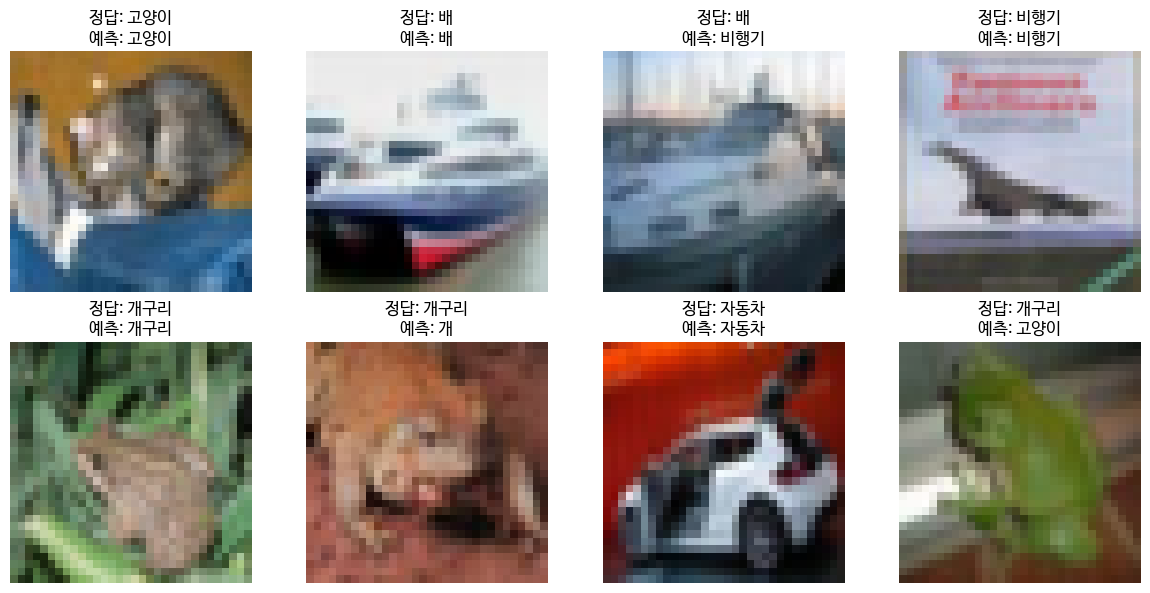

In [17]:
# 시각화

plt.figure(figsize=(12,6))
for i in range(8):
  plt.subplot(2,4, i+1)
  img = images[i].cpu().permute(1,2,0) * 0.5 + 0.5 # 역정규화(정규화 복원)
  plt.imshow(img)
  plt.title(f"정답: {classes[labels[i]]}\n예측: {classes[preds[i]]}")

  plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# eos